

## Task 2: Supervised ML Regression – Predicting University Student GPA

In this task, a regression model is built to predict the final cumulative GPA of undergraduate students using academic and demographic features from the student performance dataset. Proper preprocessing and time-aware data splitting are applied to avoid data leakage. The model is evaluated using regression metrics, and real-world insights are discussed to understand factors affecting student performance.



In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load Uploaded Dataset
df = pd.read_csv('StudentsAcademic Performance Dataset.csv')


print(df.head())
print(df.info())




  gender NationalITy PlaceofBirth     StageID GradeID SectionID Topic  \
0      M          KW       KuwaIT  lowerlevel    G-04         A    IT   
1      M          KW       KuwaIT  lowerlevel    G-04         A    IT   
2      M          KW       KuwaIT  lowerlevel    G-04         A    IT   
3      M          KW       KuwaIT  lowerlevel    G-04         A    IT   
4      M          KW       KuwaIT  lowerlevel    G-04         A    IT   

  Semester Relation  raisedhands  VisITedResources  AnnouncementsView  \
0        F   Father           15                16                  2   
1        F   Father           20                20                  3   
2        F   Father           10                 7                  0   
3        F   Father           30                25                  5   
4        F   Father           40                50                 12   

   Discussion ParentAnsweringSurvey ParentschoolSatisfaction  \
0          20                   Yes                     Go

In [24]:
# Map Class to numeric GPA (proxy target)
gpa_map = {'L': 2.0, 'M': 3.0, 'H': 3.8}
df['Final_GPA'] = df['Class'].map(gpa_map)

df[['Class', 'Final_GPA']].head()

,Class,Final_GPA
0,M,3.0
1,M,3.0
2,L,2.0
3,L,2.0
4,M,3.0


gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Final_GPA                   0
dtype: int64


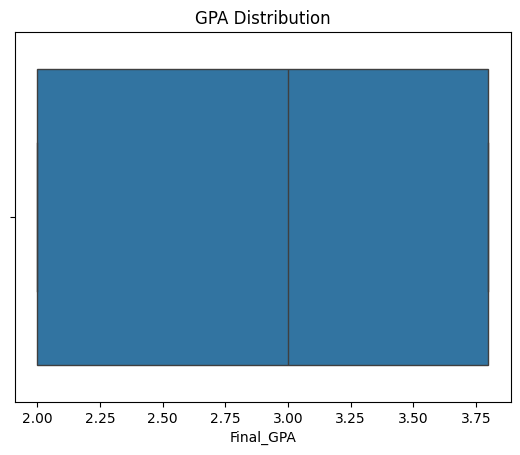

In [25]:
# Drop target leakage columns
df_model = df.drop(columns=['Class'])  # Class removed


print(df_model.isnull().sum())

import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=df['Final_GPA'])
plt.title("GPA Distribution")
plt.show()

In [26]:
# Convert categorical to dummy variables
df_encoded = pd.get_dummies(df_model, drop_first=True)

X = df_encoded.drop(columns=['Final_GPA'])
y = df_encoded['Final_GPA']

print(X.shape)

(480, 60)


In [29]:
import numpy as np

# Select only numeric columns
numeric_cols = X.select_dtypes(include=[np.number])

# Apply winsorization
X[numeric_cols.columns] = numeric_cols.clip(
    lower=numeric_cols.quantile(0.01),
    upper=numeric_cols.quantile(0.99),
    axis=1
)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
# Simulate time-aware split using StageID
train_idx = df['StageID'].isin(['MiddleSchool', 'HighSchool'])
test_idx  = df['StageID'].isin(['lowerlevel'])

X_train = X_scaled[train_idx]
X_test  = X_scaled[test_idx]
y_train = y[train_idx]
y_test  = y[test_idx]

print(X_train.shape, X_test.shape)

(281, 60) (199, 60)


In [33]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

ridge = Ridge()
rf = RandomForestRegressor(random_state=42)
svr = SVR()

ridge.fit(X_train, y_train)
rf.fit(X_train, y_train)
svr.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {'Ridge': ridge, 'RandomForest': rf, 'SVR': svr}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = [mae, rmse, r2]
    print(name, "MAE:", mae, "RMSE:", rmse, "R2:", r2)

Ridge MAE: 0.3540747169972145 RMSE: 0.43988473504918896 R2: 0.6070149305752037
RandomForest MAE: 0.3178994974874367 RMSE: 0.4221081097081731 R2: 0.6381357660984264
SVR MAE: 0.3700749582741554 RMSE: 0.4480814374542009 R2: 0.5922329081390085


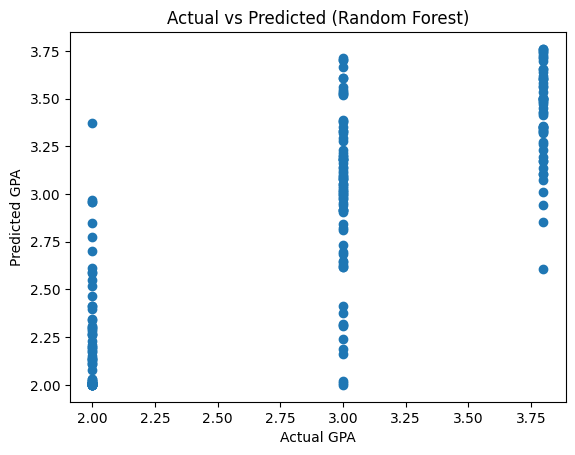

In [35]:
plt.scatter(y_test, rf.predict(X_test))
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

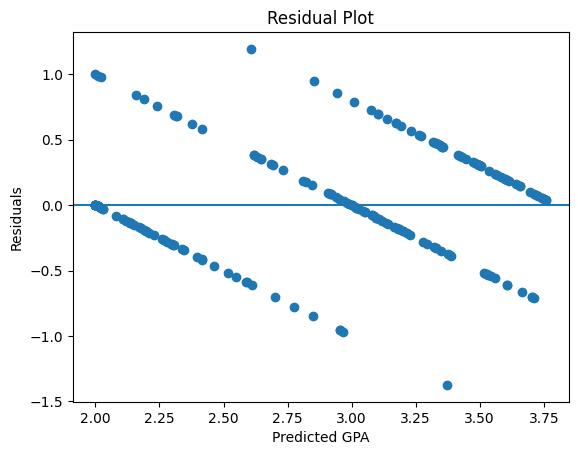

In [36]:
residuals = y_test - rf.predict(X_test)

plt.scatter(rf.predict(X_test), residuals)
plt.axhline(0)
plt.xlabel("Predicted GPA")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

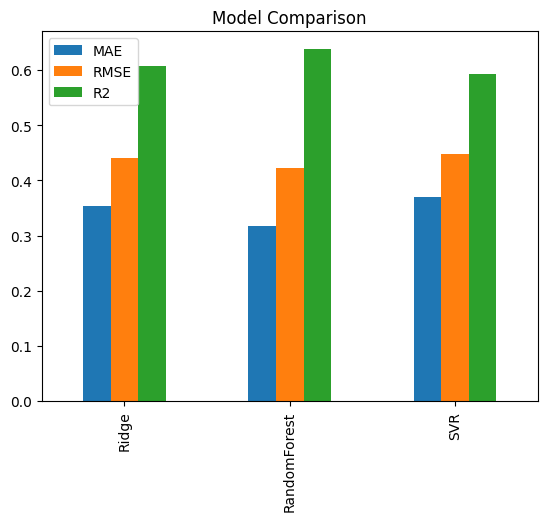

In [37]:
import pandas as pd

results_df = pd.DataFrame(results, index=['MAE','RMSE','R2']).T
results_df.plot(kind='bar')
plt.title("Model Comparison")
plt.show()